In [ ]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import xgboost, lightgbm, catboost, shap, streamlit
print("All packages loaded successfully")

c:\Users\rohit\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All packages loaded successfully


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.float_format", lambda x: "%.3f" % x)

In [ ]:
df = pd.read_csv("../data/creditcard.csv")
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Shape: (284807, 31)
Missing values: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.000,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,...,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.620,0
1,0.000,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,...,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.690,0
2,1.000,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,0.248,-1.515,...,0.248,0.772,0.909,-0.689,-0.328,-0.139,-0.055,-0.060,378.660,0
3,1.000,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,...,-0.108,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,123.500,0
4,2.000,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,...,-0.009,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,69.990,0


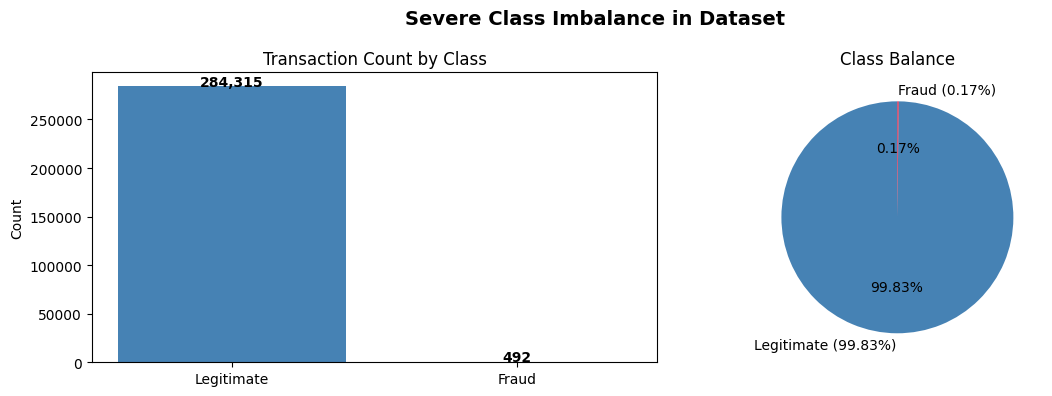


Fraud is only 0.1727% of the dataset


In [ ]:
counts = df["Class"].value_counts()
fraud_pct = counts[1] / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(["Legitimate", "Fraud"], counts.values, color=["steelblue", "crimson"])
axes[0].set_title("Transaction Count by Class")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontweight="bold")

# Pie chart
axes[1].pie(counts.values, labels=["Legitimate (99.83%)", f"Fraud ({fraud_pct:.2f}%)"],
            colors=["steelblue", "crimson"], autopct="%1.2f%%", startangle=90)
axes[1].set_title("Class Balance")

plt.suptitle("Severe Class Imbalance in Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../class_distribution.png", dpi=150)
plt.show()
print(f"\nFraud is only {fraud_pct:.4f}% of the dataset")

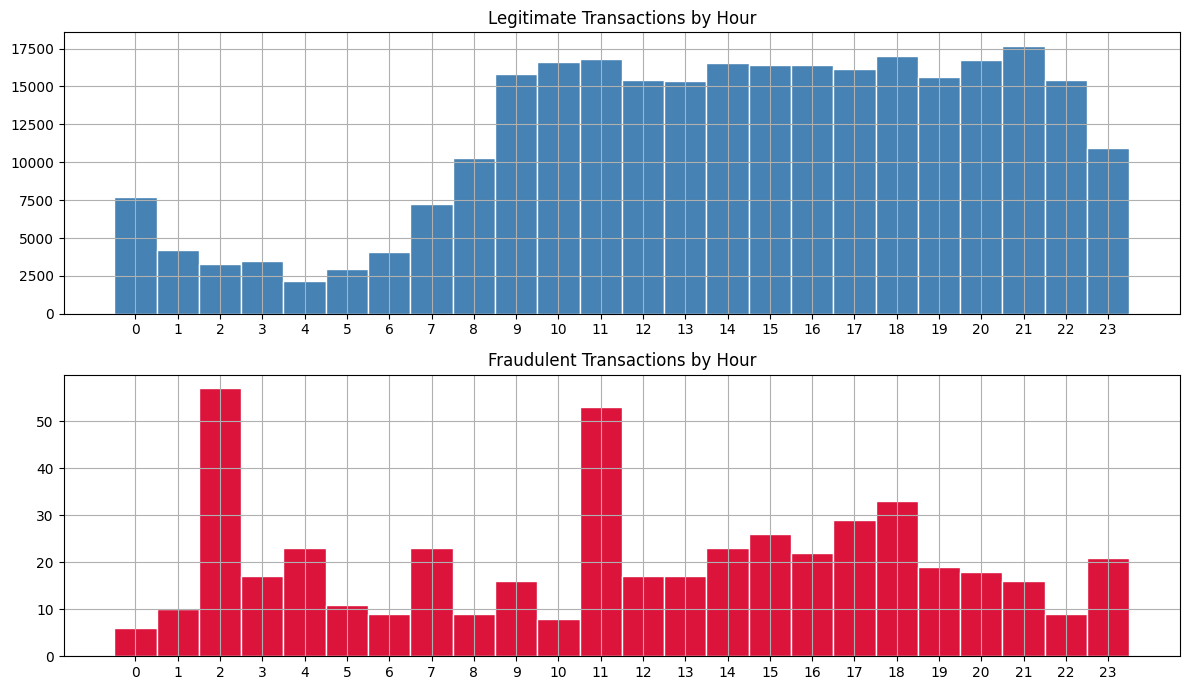

In [ ]:
df["Hour"] = (df["Time"] / 3600 % 24).astype(int)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

df[df["Class"] == 0]["Hour"].hist(bins=np.arange(25) - 0.5, ax=axes[0],
                                   color="steelblue", edgecolor="white")
axes[0].set_title("Legitimate Transactions by Hour")
axes[0].set_xticks(range(24))

df[df["Class"] == 1]["Hour"].hist(bins=np.arange(25) - 0.5, ax=axes[1],
                                   color="crimson", edgecolor="white")
axes[1].set_title("Fraudulent Transactions by Hour")
axes[1].set_xticks(range(24))

plt.tight_layout()
plt.show()

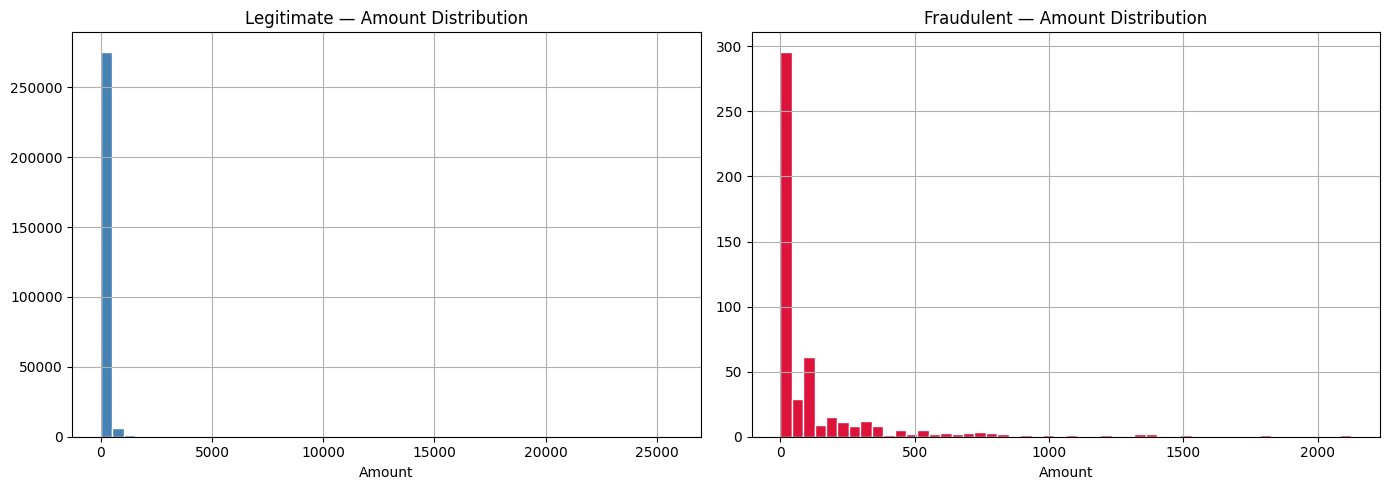

,Legitimate,Fraudulent
count,284315.000,492.000
mean,88.291,122.211
std,250.105,256.683
min,0.000,0.000
25%,5.650,1.000
50%,22.000,9.250
75%,77.050,105.890
max,25691.160,2125.870


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df["Class"] == 0]["Amount"].hist(bins=50, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Legitimate — Amount Distribution")
axes[0].set_xlabel("Amount")

df[df["Class"] == 1]["Amount"].hist(bins=50, ax=axes[1], color="crimson", edgecolor="white")
axes[1].set_title("Fraudulent — Amount Distribution")
axes[1].set_xlabel("Amount")

plt.tight_layout()
plt.show()

# Stats comparison
leg = df[df["Class"] == 0]["Amount"].describe().rename("Legitimate")
frd = df[df["Class"] == 1]["Amount"].describe().rename("Fraudulent")
pd.concat([leg, frd], axis=1)

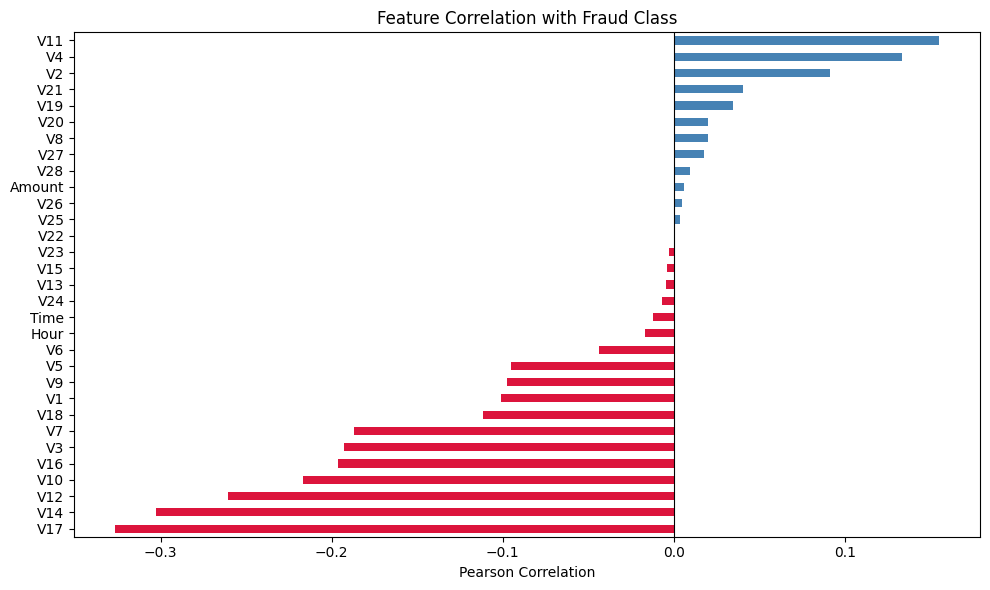

In [ ]:
fraud_corr = df.corr()["Class"].drop("Class").sort_values()

plt.figure(figsize=(10, 6))
fraud_corr.plot(kind="barh", color=["crimson" if x < 0 else "steelblue" for x in fraud_corr])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Feature Correlation with Fraud Class")
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

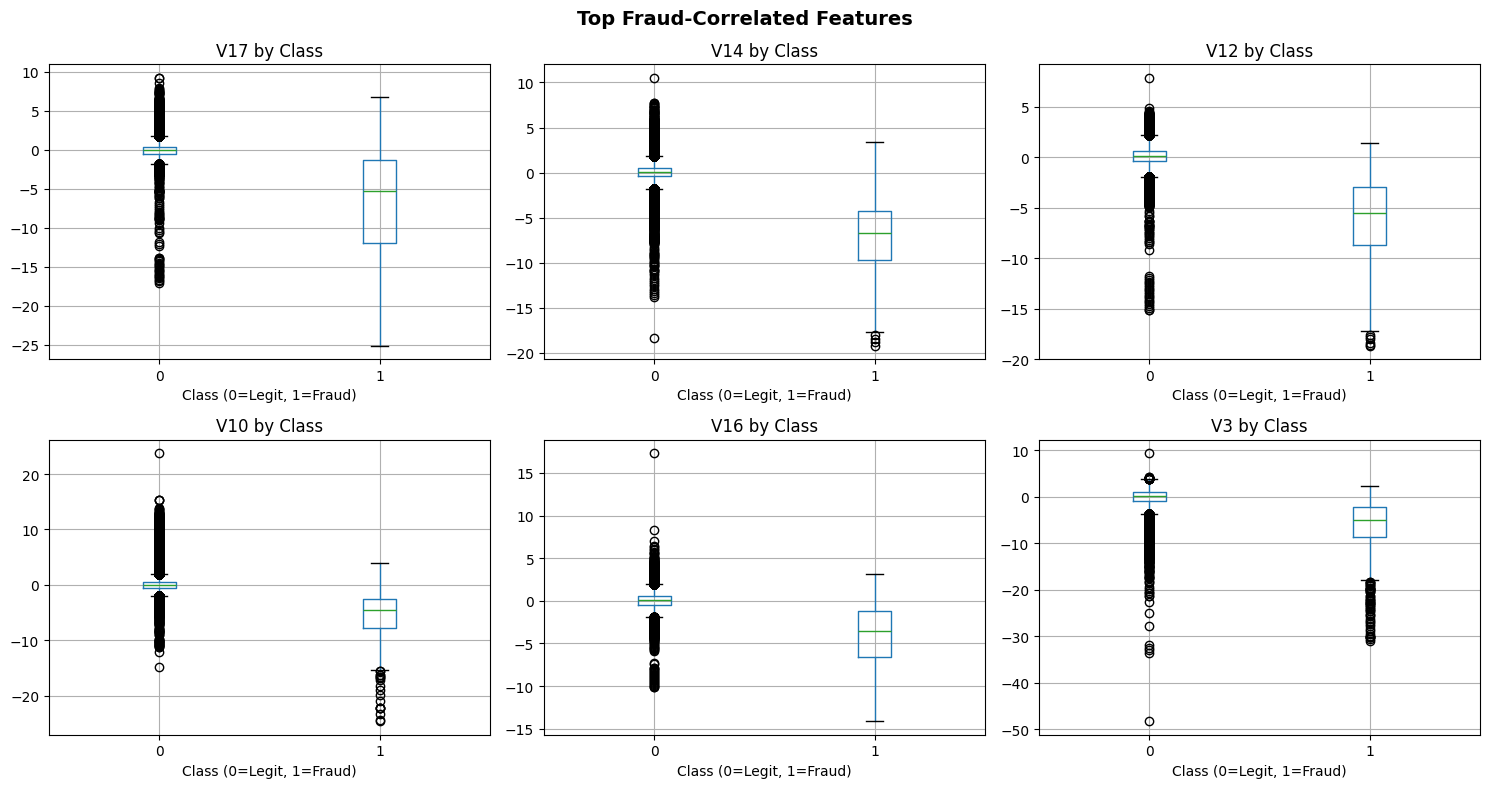

In [ ]:
top_features = fraud_corr.abs().nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    df.boxplot(column=feat, by="Class", ax=axes[i])
    axes[i].set_title(f"{feat} by Class")
    axes[i].set_xlabel("Class (0=Legit, 1=Fraud)")

plt.suptitle("Top Fraud-Correlated Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
df.to_csv("../data/creditcard_with_hour.csv", index=False)
print("Saved to data/creditcard_with_hour.csv")

Saved to data/creditcard_with_hour.csv
